## using the inverse probability weighting method to generate corrected runtimes arrays to be subsampled from and mixed

In [20]:
### Compiling RunTimes from directory of CSV files
## may also want to do this later with parquets could make it more intesting but to start keep it simple stupud

from pathlib import Path
import pandas as pd
import numpy as np

def compile_runtimes(directory):
    """
    Compile all values from the 'RunTime' column across all CSV files.

    Parameters
    ----------
    directory : str or Path
        Directory containing CSV files.

    Returns
    -------
    runtimes : np.ndarray
        Array of all runtime values.

    n_files : int
        Number of CSV files that contained a 'RunTime' column.
    """
    runtimes = []
    n_files = 0

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)

        if "RunTime" in df.columns:
            runtimes.extend(df["RunTime"].dropna())
            n_files += 1

    return np.array(runtimes), n_files

In [49]:
## Get runtimes 
runtime_array, n_runs = compile_runtimes("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/hablab_jata_highV/merged")

print("total number of runtimes:", len(runtime_array))
print("Total unique runtimes:", len(np.unique(runtime_array)))
print(runtime_array[:10])
print(f"Number of files processed: {n_runs}")

total number of runtimes: 546548
Total unique runtimes: 538264
[1.00561415 1.6200803  1.92147352 3.34809028 4.88911241 5.06947049
 5.64553602 6.39977431 6.70613932 7.5064605 ]
Number of files processed: 54


In [50]:
weights = np.load("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/jataHighV_weights.npy")
print(f"Number times: {len(runtime_array)}")
print(f"Are the lengths equal? {len(weights) == len(runtime_array)}")

Number times: 546548
Are the lengths equal? True


In [42]:
import json
import numpy as np
import pandas as pd
from pathlib import Path


def build_corrected_arrival_list(
    df: pd.DataFrame,
    time_col: str = "arrival_time",
    weight_col: str = "weight",
    seed: int | None = None,
    keep_observed_once: bool = True,
    inhibit_time: float = 0.08
) -> dict:
    """
    Build a corrected pseudo-population of arrival times from IPW weights.

    Each observed arrival is expanded into an integer number of pseudo-arrivals.
    The number of copies is sampled from a Poisson distribution with mean equal
    to the IPW weight. This preserves randomness while creating a corrected list
    you can later resample from.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain arrival times and weights.
    time_col : str
        Column name for arrival times.
    weight_col : str
        Column name for IPW weights.
    seed : int or None
        Random seed for reproducibility.
    keep_observed_once : bool
        If True, each observed arrival contributes at least one copy before
        adding Poisson extra copies. If False, total copies are drawn directly
        from Poisson(weight).
    inhibit_time : float
        Maximum time window to jitter the pseudo-arrivals. Each pseudo-arrival
        is sampled uniformly from [arrival_time, arrival_time + inhibit_time].

    Returns
    -------
    dict
        JSON-serializable object with corrected arrival times and metadata.
    """
    rng = np.random.default_rng(seed)

    work = df[[time_col, weight_col]].dropna().copy()
    work[weight_col] = work[weight_col].astype(float)
    work = work[work[weight_col] > 0]

    corrected_times = []
    source_map = []

    for idx, row in work.reset_index(drop=True).iterrows():
        t = float(row[time_col])
        w = float(row[weight_col])

        if keep_observed_once:
            n_copies = 1 + rng.poisson(max(w - 1.0, 0.0)) ## This is the issue I should maybe sample from poisson distrib with sd of inhibit_time/2
        else:
            n_copies = rng.poisson(w)

        for _ in range(n_copies):
            jittered_t = rng.uniform(t, t + inhibit_time) ## this now samples n number of times from uniform distrib from t, t+inhibit_time logic is that is when we are missing particles in that time frame
            corrected_times.append(jittered_t)
            source_map.append(int(idx))

    corrected_times = sorted(corrected_times)

    return {
        "method": "ipw_poisson_expansion",
        "seed": seed,
        "keep_observed_once": keep_observed_once,
        "n_observed": int(len(work)),
        "n_corrected": int(len(corrected_times)),
        "arrival_times": corrected_times,
        "source_index": source_map,
    }


def save_corrected_arrivals(result: dict, output_path: str | Path) -> None:
    output_path = Path(output_path)
    with output_path.open("w") as f:
        json.dump(result, f, indent=2)

In [51]:
df = pd.DataFrame({"RunTime": runtime_array, "IPW": weights})

In [52]:
result = build_corrected_arrival_list(
    df,
    time_col="RunTime",
    weight_col="IPW",
    seed=42,
    keep_observed_once=True,
    inhibit_time=0.08
)




In [53]:
result["arrival_times"][:10]

[0.9727684521546511,
 0.9787297313354113,
 0.9914597372487556,
 1.0072357880818898,
 1.0117791648188736,
 1.020504281469728,
 1.022896806577567,
 1.04072442448572,
 1.049920081793668,
 1.051756393791709]

In [54]:
arrival_times = result["arrival_times"]

print(f"Number of unique arrival times: {len(np.unique(arrival_times))}")
print(f"Number of total arrival times: {len(arrival_times)}")


Number of unique arrival times: 2147432
Number of total arrival times: 2147432


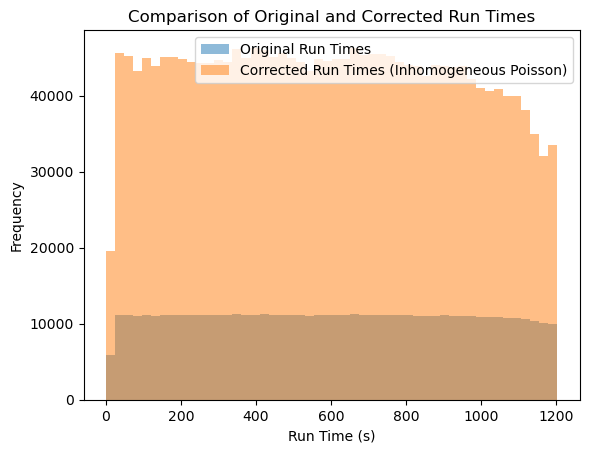

In [55]:
import matplotlib.pyplot as plt
plt.hist(runtime_array, bins=50, alpha=0.5, label="Original Run Times")
plt.hist(result["arrival_times"], bins=50, alpha=0.5, label="Corrected Run Times (Inhomogeneous Poisson)")
plt.xlabel("Run Time (s)")
plt.ylabel("Frequency")
plt.title("Comparison of Original and Corrected Run Times")
plt.legend()

In [56]:
save_corrected_arrivals(result, "/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/jataHighV_corrected_arrivals.json")